# Teste de pipeline dois modelos de regressão logística

## Imports

In [1]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from tqdm import tqdm

import spacy
nlp = spacy.load("en_core_web_sm", enable=["tokenizer"])

from sklearn.model_selection import train_test_split

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cinth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df_custom = pd.read_csv('../custom_dataset_v2_mini.csv', delimiter=";")
df_custom.head()

,ID,Label,Text,word_count
0,25454,Google,We propose a new global entity disambiguation ...,33
1,5152,Google,Newton's laws and Newtonian mechanics in gener...,43
2,27268,Google,3 April 2017 Last updated at 09:17 BST Demand ...,35
3,29161,Google,Southern California contains a Mediterranean c...,32
4,45531,Google,NASA scientists discovered cyclopropenylidene ...,33


In [3]:
df_exe = pd.read_csv('../dataset-exemplos.csv', delimiter=";")
df_exe.head()

,ID,Text,Label
0,D1-1,"It is an approximation useful in chemistry, bu...",Human
1,D1-10,"Within 50 million years, the pressure and dens...",Human
2,D1-100,Educational robotics has a wide range of appli...,OpenAI
3,D1-101,Metabolic engineering is a field of biotechnol...,Meta
4,D1-102,Metabolic engineering is a multidisciplinary f...,Anthropic


In [4]:
df_exe["word_count"] = len(df_exe["Text"].str.split())

In [5]:
df = pd.concat([df_custom, df_exe])

In [6]:
df["generated"] = df["Label"] != "Human"
df.head()

,ID,Label,Text,word_count,generated
0,25454,Google,We propose a new global entity disambiguation ...,33,True
1,5152,Google,Newton's laws and Newtonian mechanics in gener...,43,True
2,27268,Google,3 April 2017 Last updated at 09:17 BST Demand ...,35,True
3,29161,Google,Southern California contains a Mediterranean c...,32,True
4,45531,Google,NASA scientists discovered cyclopropenylidene ...,33,True


In [7]:
df["Label"].value_counts()

Label
Human        70662
Meta         30017
OpenAI       30017
Google       30016
Anthropic    10328
Name: count, dtype: int64

In [8]:
df["generated"].value_counts()

generated
True     100378
False     70662
Name: count, dtype: int64

In [9]:
df_s1 = pd.read_csv('../subm1_labels_revealed.csv', delimiter=";")
df_s2 = pd.read_csv('../subm2_labels_revealed.csv', delimiter=";")
df_val = pd.concat([df_s1, df_s2])
df_val.head()

,ID,Text,Label
0,D2-1,A covalent bond is a chemical bond that involv...,Human
1,D2-2,A covalent bond forms when two atoms share one...,Anthropic
2,D2-3,A covalent bond is a type of chemical bond whe...,OpenAI
3,D2-4,A covalent bond is a chemical bond that involv...,Meta
4,D2-5,Driven by exciting developments in the field o...,Human


In [10]:
df_val["Label"].value_counts()

Label
Human        68
Google       35
Meta         34
Anthropic    33
OpenAI       30
Name: count, dtype: int64

In [11]:
df_val["generated"] = df_val["Label"] != "Human"
df_val["generated"].value_counts()

generated
True     132
False     68
Name: count, dtype: int64

In [138]:
df_s3 = pd.read_csv('../subm3.csv', delimiter=";")
df_s3

,ID,Text
0,D2-126,The reality about the places that diamonds are...
1,D2-127,Geothermobarometric calculations for a worldwi...
2,D2-128,Diamonds are formed deep within the Earth’s ma...
3,D2-129,Diamond is a solid form of the element carbon ...
4,D2-130,Diamonds are formed deep within the Earth unde...
...,...,...
145,D4-96,Gold nanoclusters are widely used in medical i...
146,D4-97,Gold nanoparticles are incredibly tiny particl...
147,D4-98,Gold nanoparticles are tiny gold structures me...
148,D4-99,Gold nanoparticles in chemotherapy and radioth...


## Preprocessing

In [139]:
def preprocessing(text):
    # Removendo distinção ente maiúsculas e minúsculas
    text = text.lower()

    # Removendo caracteres numéricos e espaços    
    text = re.sub(r"[\d\s]+", " ", text)

    # Tokenização
    tokens = [token.text for token in nlp(text)]

    # Removendo stop-words
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    return " ".join(tokens)

In [ ]:
df["treated_text"] = df["Text"].apply(preprocessing)
df.head()

In [ ]:
df_val["treated_text"] = df_val["Text"].apply(preprocessing)
df_val.head()

,ID,Text,Label,generated,treated_text
0,D2-1,A covalent bond is a chemical bond that involv...,Human,False,covalent bond chemical bond involves sharing e...
1,D2-2,A covalent bond forms when two atoms share one...,Anthropic,True,covalent bond forms two atoms share one pairs ...
2,D2-3,A covalent bond is a type of chemical bond whe...,OpenAI,True,covalent bond type chemical bond two atoms sha...
3,D2-4,A covalent bond is a chemical bond that involv...,Meta,True,covalent bond chemical bond involves sharing e...
4,D2-5,Driven by exciting developments in the field o...,Human,False,driven exciting developments field nanotechnol...


In [141]:
df_s3["treated_text"] = df_s3["Text"].apply(preprocessing)
df_s3.head()

,ID,Text,treated_text
0,D2-126,The reality about the places that diamonds are...,reality places diamonds found planet might hos...
1,D2-127,Geothermobarometric calculations for a worldwi...,geothermobarometric calculations worldwide dat...
2,D2-128,Diamonds are formed deep within the Earth’s ma...,diamonds formed deep within earth ’s mantle ex...
3,D2-129,Diamond is a solid form of the element carbon ...,diamond solid form element carbon atoms arrang...
4,D2-130,Diamonds are formed deep within the Earth unde...,diamonds formed deep within earth extreme cond...


## Pipeline

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Model 1: Classificação Binária - campo "generated"

In [16]:
df_bin = df.groupby("generated").sample(50000, random_state=42)
df_bin.generated.value_counts()

generated
False    50000
True     50000
Name: count, dtype: int64

In [21]:
X_train, X_test, y_train, y_test = train_test_split(df_bin["treated_text"], df_bin["generated"], test_size=0.25, random_state=42)

In [22]:
print("X_train: ", len(X_train))
print("y_train: ", len(y_train))
print("X_test: ", len(X_test))
print("y_test: ", len(y_test))

X_train:  75000
y_train:  75000
X_test:  25000
y_test:  25000


In [29]:
pipeline = Pipeline([
    ('count_vectorizer', CountVectorizer()),  # Step 1: CountVectorizer
    ('tfidf_transformer', TfidfTransformer()),  # Step 2: TF-IDF Transformer
    ('classifier', LogisticRegression())
])

In [30]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('count_vectorizer', ...), ('tfidf_transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [31]:
y_pred = pipeline.predict(X_test)

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.75      0.76      0.76     12528
        True       0.76      0.74      0.75     12472

    accuracy                           0.75     25000
   macro avg       0.75      0.75      0.75     25000
weighted avg       0.75      0.75      0.75     25000



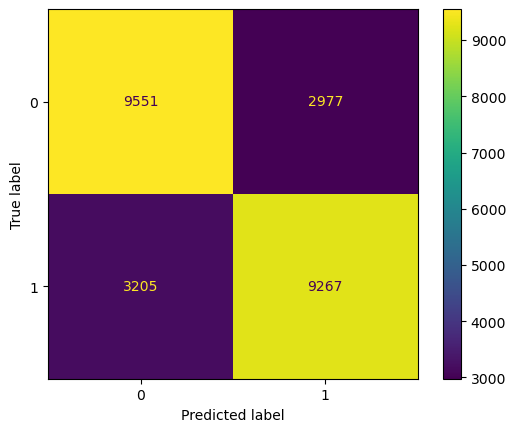

In [33]:
cm = confusion_matrix(y_test, y_pred)
cm_diplay = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_diplay.plot(values_format='')

In [34]:
from pickle import dump
with open("bin_generated.pkl", "wb") as f:
    dump(pipeline, f, protocol=5)

In [38]:
val_pred = pipeline.predict(df_val["treated_text"])
print(classification_report(df_val["generated"], val_pred))

              precision    recall  f1-score   support

       False       0.50      0.76      0.60        68
        True       0.83      0.61      0.70       132

    accuracy                           0.66       200
   macro avg       0.67      0.69      0.65       200
weighted avg       0.72      0.66      0.67       200



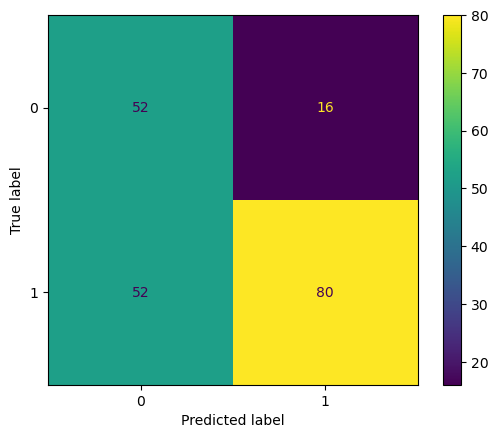

In [39]:
cm = confusion_matrix(df_val["generated"], val_pred)
cm_diplay = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_diplay.plot(values_format='')

### Model 2 - Classificação das Empresas

In [60]:
df_nh = df[df["Label"] != "Human"]
df_nh.Label.value_counts()

Label
Meta         30017
OpenAI       30017
Google       30016
Anthropic    10328
Name: count, dtype: int64

In [61]:
X_train, X_test, y_train, y_test = train_test_split(df_nh["treated_text"], df_nh["Label"],test_size=0.25,random_state=42)

In [62]:
print("X_train: ", len(X_train))
print("y_train: ", len(y_train))
print("X_test: ", len(X_test))
print("y_test: ", len(y_test))

X_train:  75283
y_train:  75283
X_test:  25095
y_test:  25095


In [63]:
pipeline = Pipeline([
    ('count_vectorizer', CountVectorizer()),  # Step 1: CountVectorizer
    ('tfidf_transformer', TfidfTransformer()),  # Step 2: TF-IDF Transformer
    ('classifier', LogisticRegression(solver="newton-cg"))
])

In [64]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('count_vectorizer', ...), ('tfidf_transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [65]:
y_pred = pipeline.predict(X_test)

In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Anthropic       0.99      0.96      0.97      2555
      Google       0.70      0.82      0.75      7444
        Meta       0.69      0.67      0.68      7688
      OpenAI       0.71      0.62      0.66      7408

    accuracy                           0.73     25095
   macro avg       0.77      0.77      0.77     25095
weighted avg       0.73      0.73      0.73     25095



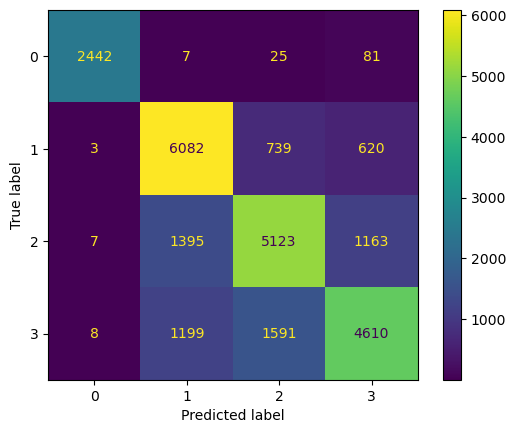

In [67]:
cm = confusion_matrix(y_test, y_pred)
cm_diplay = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_diplay.plot(values_format='')

In [68]:
from pickle import dump
with open("mul_label.pkl", "wb") as f:
    dump(pipeline, f, protocol=5)

## Validação

In [69]:
from pickle import load
with open("bin_generated.pkl", "rb") as f:
    bg = load(f)

In [77]:
df_val["bg"] = bg.predict(df_val["treated_text"])
df_val

,ID,Text,Label,generated,treated_text,bg
0,D2-1,A covalent bond is a chemical bond that involv...,Human,False,covalent bond chemical bond involves sharing e...,False
1,D2-2,A covalent bond forms when two atoms share one...,Anthropic,True,covalent bond forms two atoms share one pairs ...,True
2,D2-3,A covalent bond is a type of chemical bond whe...,OpenAI,True,covalent bond type chemical bond two atoms sha...,False
3,D2-4,A covalent bond is a chemical bond that involv...,Meta,True,covalent bond chemical bond involves sharing e...,False
4,D2-5,Driven by exciting developments in the field o...,Human,False,driven exciting developments field nanotechnol...,True
...,...,...,...,...,...,...
95,D3-71,"In evolutionary computation, an initial set of...",Human,False,"evolutionary computation , initial set candida...",False
96,D3-72,Evolutionary computation is a family of algori...,OpenAI,True,evolutionary computation family algorithms ins...,True
97,D3-73,Evolutionary Computation (EC) comprises metahe...,Google,True,evolutionary computation ( ec ) comprises meta...,True
98,D3-74,"At this point, most researchers start 'tuning'...",Human,False,"point , researchers start ' tuning ' fitness f...",True


In [74]:
from pickle import load
with open("mul_label.pkl", "rb") as f:
    ml = load(f)

In [129]:
def predict(text, bg):
    if bg:
        # Predição se for texto generativo
        return ml.predict([text])[0]
    else:
        return "Human"

In [130]:
df_val["ml"] = df_val.apply(lambda row: predict(row["treated_text"], row.bg), axis=1)
df_val.ml.value_counts(dropna=False)

ml
Human        104
OpenAI        73
Anthropic      9
Google         9
Meta           5
Name: count, dtype: int64

In [131]:
print(classification_report(df_val["Label"], df_val["ml"]))

              precision    recall  f1-score   support

   Anthropic       0.00      0.00      0.00        33
      Google       0.22      0.06      0.09        35
       Human       0.50      0.76      0.60        68
        Meta       0.00      0.00      0.00        34
      OpenAI       0.18      0.43      0.25        30

    accuracy                           0.34       200
   macro avg       0.18      0.25      0.19       200
weighted avg       0.24      0.34      0.26       200



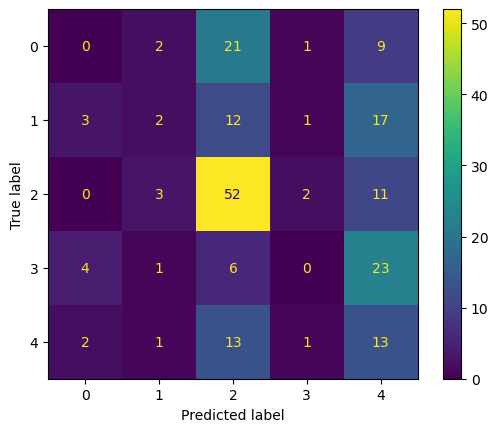

In [134]:
cm = confusion_matrix(df_val["Label"], df_val["ml"])
cm_diplay = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_diplay.plot(values_format='')

## Submissão 3 A

In [142]:
from pickle import load
with open("bin_generated.pkl", "rb") as f:
    bg = load(f)

In [143]:
df_s3["bg"] = bg.predict(df_s3["treated_text"])
df_s3

,ID,Text,treated_text,bg
0,D2-126,The reality about the places that diamonds are...,reality places diamonds found planet might hos...,True
1,D2-127,Geothermobarometric calculations for a worldwi...,geothermobarometric calculations worldwide dat...,False
2,D2-128,Diamonds are formed deep within the Earth’s ma...,diamonds formed deep within earth ’s mantle ex...,True
3,D2-129,Diamond is a solid form of the element carbon ...,diamond solid form element carbon atoms arrang...,False
4,D2-130,Diamonds are formed deep within the Earth unde...,diamonds formed deep within earth extreme cond...,True
...,...,...,...,...
145,D4-96,Gold nanoclusters are widely used in medical i...,gold nanoclusters widely used medical imaging ...,True
146,D4-97,Gold nanoparticles are incredibly tiny particl...,gold nanoparticles incredibly tiny particles g...,False
147,D4-98,Gold nanoparticles are tiny gold structures me...,gold nanoparticles tiny gold structures measur...,True
148,D4-99,Gold nanoparticles in chemotherapy and radioth...,gold nanoparticles chemotherapy radiotherapy u...,True


In [144]:
from pickle import load
with open("mul_label.pkl", "rb") as f:
    ml = load(f)

In [145]:
def predict(text, bg):
    if bg:
        # Predição se for texto generativo
        return ml.predict([text])[0]
    else:
        return "Human"

In [146]:
df_s3["ml"] = df_s3.apply(lambda row: predict(row["treated_text"], row.bg), axis=1)
df_s3.ml.value_counts(dropna=False)

ml
Human        78
OpenAI       55
Meta         10
Google        6
Anthropic     1
Name: count, dtype: int64

In [147]:
df_s3.head()

,ID,Text,treated_text,bg,ml
0,D2-126,The reality about the places that diamonds are...,reality places diamonds found planet might hos...,True,OpenAI
1,D2-127,Geothermobarometric calculations for a worldwi...,geothermobarometric calculations worldwide dat...,False,Human
2,D2-128,Diamonds are formed deep within the Earth’s ma...,diamonds formed deep within earth ’s mantle ex...,True,OpenAI
3,D2-129,Diamond is a solid form of the element carbon ...,diamond solid form element carbon atoms arrang...,False,Human
4,D2-130,Diamonds are formed deep within the Earth unde...,diamonds formed deep within earth extreme cond...,True,OpenAI


In [149]:
df_s3 = df_s3[["ID", "ml"]]
df_s3.to_csv("subm3.csv", sep=";", index=False)
